# Notebook 03 — Feature Engineering & Transformation

**Project:** Customer Churn ETL & Analytics Pipeline  
**Student:** Divyesh Joshi | MC24097 | MCA-II Sem IV  
**Institute:** IIMS Chinchwad, Pune — Savitribai Phule Pune University  

---

## Objective
This notebook covers **Phase 3 — Transformation & Feature Engineering**:
- Encode binary and multi-class categorical columns
- Create tenure groups
- Engineer new features: RevenueCategory, AnnualRevenue, LoyaltyScore
- Validate transformed dataset
- Analyse feature correlations with churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Load cleaned data from notebook 02
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.drop_duplicates(inplace=True)
for col in df.select_dtypes('object').columns:
    df[col] = df[col].str.strip()

print(f'Loaded cleaned data: {df.shape}')

Loaded cleaned data: (7043, 21)


## 1. Encode Binary Columns

In [2]:
# Churn: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype(int)

# Gender: Male=1, Female=0
df['gender_encoded'] = df['gender'].map({'Male': 1, 'Female': 0}).astype(int)

# Yes/No columns
yn_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in yn_cols:
    df[f'{col}_encoded'] = df[col].map({'Yes': 1, 'No': 0}).astype(int)

print('Binary encodings applied:')
enc_cols = ['Churn','gender_encoded'] + [f'{c}_encoded' for c in yn_cols]
print(df[enc_cols].head(5))

Binary encodings applied:
   Churn  gender_encoded  Partner_encoded  Dependents_encoded  \
0      0               0                1                   0   
1      0               1                0                   0   
2      1               1                0                   0   
3      0               1                0                   0   
4      1               0                0                   0   

   PhoneService_encoded  PaperlessBilling_encoded  
0                     0                         1  
1                     1                         0  
2                     1                         1  
3                     0                         0  
4                     1                         1  


## 2. One-Hot Encode Multi-Class Columns

In [3]:
# Save originals for analysis
contract_orig = df['Contract'].copy()
internet_orig = df['InternetService'].copy()
payment_orig  = df['PaymentMethod'].copy()

ohe_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
            'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
            'Contract','PaymentMethod']

df_encoded = pd.get_dummies(df, columns=ohe_cols, drop_first=False)

# Restore originals
df_encoded['Contract']        = contract_orig
df_encoded['InternetService'] = internet_orig
df_encoded['PaymentMethod']   = payment_orig

print(f'Shape after OHE: {df_encoded.shape}')
print(f'New columns added: {df_encoded.shape[1] - df.shape[1]}')

Shape after OHE: (7043, 50)
New columns added: 24


## 3. Tenure Group Feature

Churn rate by tenure group:
              Churned  Total  Churn Rate %
tenure_group                              
0-1 Year         1037   2175          47.7
1-2 Years         294   1024          28.7
2-4 Years         325   1594          20.4
4-6 Years         213   2239           9.5


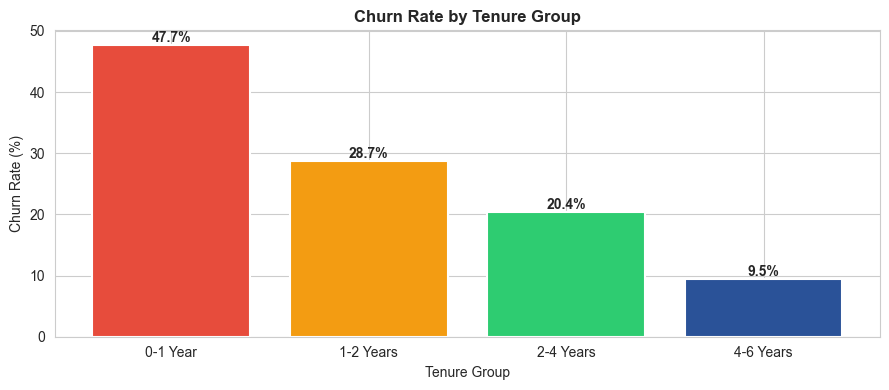

Observation: Customers in first year have highest churn rate.


In [4]:
bins   = [0, 12, 24, 48, 72]
labels = ['0-1 Year', '1-2 Years', '2-4 Years', '4-6 Years']

df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels)

# Churn rate per tenure group
tg_stats = (df.groupby('tenure_group', observed=False)['Churn']
              .agg(['sum','count'])
              .rename(columns={'sum':'Churned','count':'Total'}))
tg_stats['Churn Rate %'] = (tg_stats['Churned'] / tg_stats['Total'] * 100).round(1)

print('Churn rate by tenure group:')
print(tg_stats)

plt.figure(figsize=(9, 4))
plt.bar(tg_stats.index.astype(str), tg_stats['Churn Rate %'],
        color=['#e74c3c','#f39c12','#2ecc71','#2a5298'], edgecolor='white', linewidth=1.5)
for i, (idx, row) in enumerate(tg_stats.iterrows()):
    plt.text(i, row['Churn Rate %'] + 0.5, f"{row['Churn Rate %']:.1f}%", ha='center', fontweight='bold')
plt.title('Churn Rate by Tenure Group', fontweight='bold')
plt.xlabel('Tenure Group'); plt.ylabel('Churn Rate (%)')
plt.tight_layout(); plt.show()
print('Observation: Customers in first year have highest churn rate.')

## 4. Revenue Category Feature

Churn by Revenue Category:
                 Churned  Total  Churn Rate %
RevenueCategory                              
High                1274   3591          35.5
Low                  188   1731          10.9
Medium               407   1721          23.6


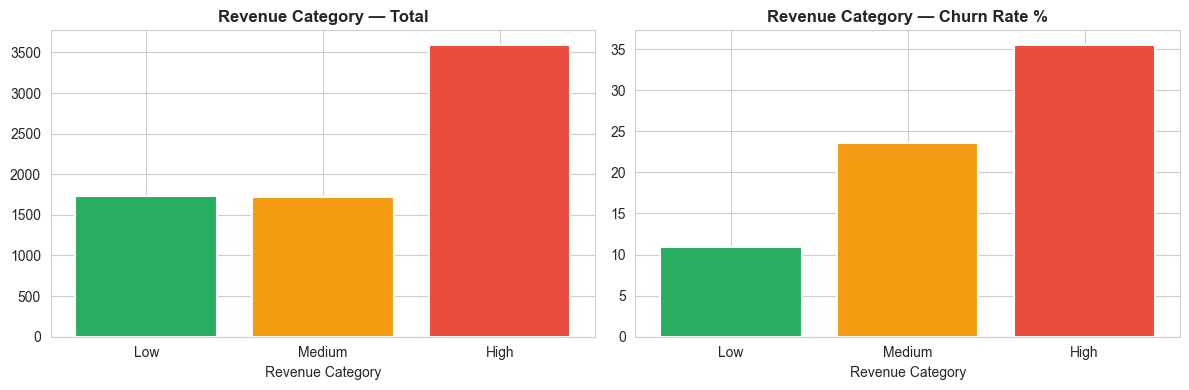

In [5]:
conditions = [
    df['MonthlyCharges'] < 35,
    (df['MonthlyCharges'] >= 35) & (df['MonthlyCharges'] < 70),
    df['MonthlyCharges'] >= 70
]
df['RevenueCategory'] = np.select(conditions, ['Low','Medium','High'], default='Low').astype(str)

rc_stats = (df.groupby('RevenueCategory')['Churn']
              .agg(['sum','count'])
              .rename(columns={'sum':'Churned','count':'Total'}))
rc_stats['Churn Rate %'] = (rc_stats['Churned'] / rc_stats['Total'] * 100).round(1)

print('Churn by Revenue Category:')
print(rc_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {'Low':'#27ae60','Medium':'#f39c12','High':'#e74c3c'}
for ax, metric in zip(axes, ['Total','Churn Rate %']):
    vals = rc_stats.reindex(['Low','Medium','High'])[metric]
    ax.bar(vals.index, vals.values,
           color=[colors[c] for c in vals.index], edgecolor='white', linewidth=1.5)
    ax.set_title(f'Revenue Category — {metric}', fontweight='bold')
    ax.set_xlabel('Revenue Category')
plt.tight_layout(); plt.show()

## 5. Additional Engineered Features

In [6]:
# Annual revenue potential
df['AnnualRevenue'] = df['MonthlyCharges'] * 12

# Loyalty score: tenure normalised 0-1
df['LoyaltyScore'] = (df['tenure'] / df['tenure'].max()).round(3)

print('New features summary:')
print(df[['AnnualRevenue','LoyaltyScore','RevenueCategory','tenure_group']].describe())
print('\nSample rows:')
print(df[['customerID','tenure','MonthlyCharges','AnnualRevenue','LoyaltyScore',
          'RevenueCategory','tenure_group']].head(8))

New features summary:
       AnnualRevenue  LoyaltyScore
count    7043.000000   7043.000000
mean      777.140310      0.449615
std       361.080565      0.341061
min       219.000000      0.000000
25%       426.000000      0.125000
50%       844.200000      0.403000
75%      1078.200000      0.764000
max      1425.000000      1.000000

Sample rows:
   customerID  tenure  MonthlyCharges  AnnualRevenue  LoyaltyScore  \
0  7590-VHVEG       1           29.85          358.2         0.014   
1  5575-GNVDE      34           56.95          683.4         0.472   
2  3668-QPYBK       2           53.85          646.2         0.028   
3  7795-CFOCW      45           42.30          507.6         0.625   
4  9237-HQITU       2           70.70          848.4         0.028   
5  9305-CDSKC       8           99.65         1195.8         0.111   
6  1452-KIOVK      22           89.10         1069.2         0.306   
7  6713-OKOMC      10           29.75          357.0         0.139   

  RevenueCategory 

## 6. Feature Correlation with Churn

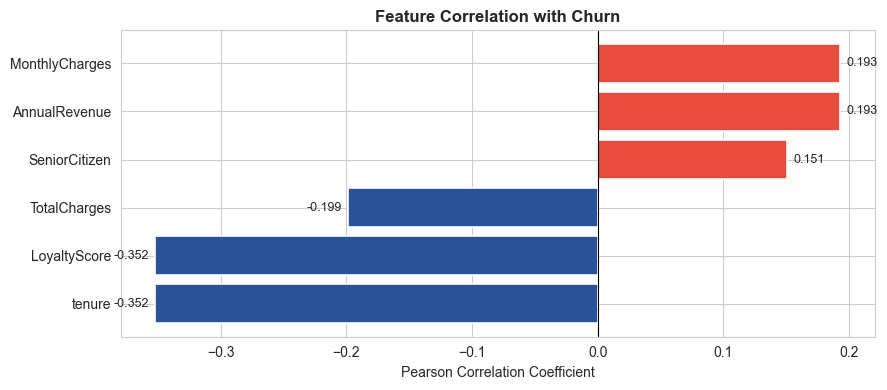

Red = positively correlated with churn | Blue = negatively correlated


In [7]:
numeric_feats = ['tenure','MonthlyCharges','TotalCharges',
                 'AnnualRevenue','LoyaltyScore','SeniorCitizen','Churn']
corr = df[numeric_feats].corr()['Churn'].drop('Churn').sort_values()

plt.figure(figsize=(9, 4))
colors = ['#e74c3c' if v > 0 else '#2a5298' for v in corr.values]
bars = plt.barh(corr.index, corr.values, color=colors, edgecolor='white', linewidth=1.2)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Churn', fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
for bar, val in zip(bars, corr.values):
    plt.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout(); plt.show()
print('Red = positively correlated with churn | Blue = negatively correlated')

## 7. Contract Type vs Churn (Key Insight)

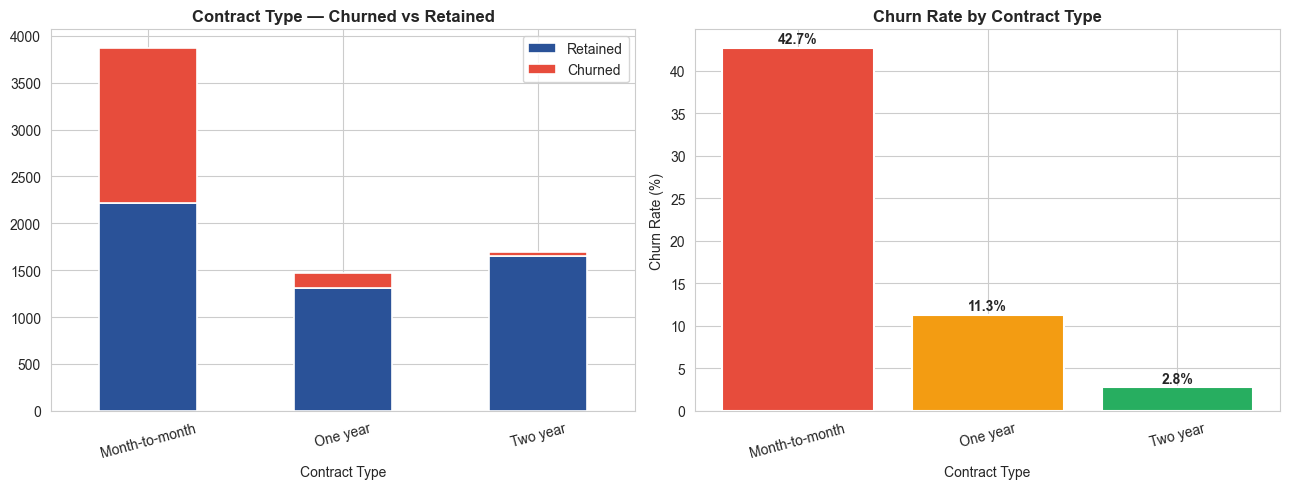

Key Insight: Month-to-month customers churn at ~43% vs only ~3% for two-year contracts!


In [8]:
ct_stats = (df.groupby('Contract')['Churn']
              .agg(['sum','count'])
              .rename(columns={'sum':'Churned','count':'Total'}))
ct_stats['Retained'] = ct_stats['Total'] - ct_stats['Churned']
ct_stats['Churn Rate %'] = (ct_stats['Churned']/ct_stats['Total']*100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct_stats[['Retained','Churned']].plot(kind='bar', ax=axes[0], stacked=True,
    color=['#2a5298','#e74c3c'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Contract Type — Churned vs Retained', fontweight='bold')
axes[0].set_xlabel('Contract Type'); axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(['Retained','Churned'])

axes[1].bar(ct_stats.index, ct_stats['Churn Rate %'],
            color=['#e74c3c','#f39c12','#27ae60'], edgecolor='white', linewidth=1.5)
for i, val in enumerate(ct_stats['Churn Rate %']):
    axes[1].text(i, val+0.5, f'{val}%', ha='center', fontweight='bold')
axes[1].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[1].set_xlabel('Contract Type'); axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()
print('Key Insight: Month-to-month customers churn at ~43% vs only ~3% for two-year contracts!')

## 8. Summary — All Engineered Features

| Feature | Type | Description |
|---|---|---|
| `Churn` | int (0/1) | Target: 1=churned, 0=retained |
| `gender_encoded` | int (0/1) | Male=1, Female=0 |
| `Partner_encoded` | int (0/1) | Yes=1, No=0 |
| `Dependents_encoded` | int (0/1) | Yes=1, No=0 |
| `PhoneService_encoded` | int (0/1) | Yes=1, No=0 |
| `PaperlessBilling_encoded` | int (0/1) | Yes=1, No=0 |
| `tenure_group` | category | 0-1yr, 1-2yr, 2-4yr, 4-6yr |
| `RevenueCategory` | string | Low / Medium / High |
| `AnnualRevenue` | float | MonthlyCharges × 12 |
| `LoyaltyScore` | float 0-1 | tenure / max_tenure |

**Next Step → Notebook 04: Visualisation & Insights**